#### The notebook contains tests on Redfield Relaxation implementation. In this file it is checked manualy with spectra comparison with linblad operarions

In [70]:
%load_ext autoreload
%autoreload 2

import sys
import os
import math
from importlib import reload

import torch

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import mars
from mars import spin_model, spectra_manager, constants, population, concat
from mars.population import RedfieldRelaxationChannel, RedfieldManager

import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [71]:
dtype = torch.float64
device = torch.device("cpu")

In [95]:
import torch
import numpy as np
import math
from typing import Optional, List, Tuple
from mars.population.contexts import Context, SummedContext
from mars.population import transform
from mars import spin_model
import mars

In [73]:
from mars import visualization

In [74]:
# Let's start from the sample creation
g_tensor = spin_model.Interaction([2.002, 2.003, 2.01], dtype=dtype, device=device)
zfs_interaction = spin_model.DEInteraction([140e6, 40e6], dtype=dtype, device=device)  # 500 and 100 MHz

base_spin_system = spin_model.SpinSystem(
    electrons=[1.0],  # S=1 triplet
    g_tensors=[g_tensor],
    electron_electron=[(0, 0, zfs_interaction)]
)

triplet = spin_model.MultiOrientedSample(
    base_spin_system=base_spin_system,
    ham_strain=0.0,
    gauss=0.0002,
    lorentz=0.0002,
    device=device,
    mesh=(20, 20),
    dtype=dtype
)

In [75]:
# Let's start from the sample creation
g_tensor = spin_model.Interaction([2.002, 2.003, 2.01], dtype=dtype, device=device)
zfs_interaction = spin_model.DEInteraction([140e6, 40e6], dtype=dtype, device=device)  # 500 and 100 MHz

base_spin_system = spin_model.SpinSystem(
    electrons=[1.0, 1.0],  # S=1 triplet
    g_tensors=[g_tensor, g_tensor],
    electron_electron=[(0, 0, zfs_interaction), (1, 1, zfs_interaction), (0, 1, zfs_interaction)]
)

triplet_double = spin_model.MultiOrientedSample(
    base_spin_system=base_spin_system,
    ham_strain=0.0,
    gauss=0.0002,
    lorentz=0.0002,
    device=device,
    mesh=(20, 20),
    dtype=dtype
)

In [76]:
init_populations = [0.502, 0.502, 0.500] # Let's make them almoust equel
init_populations  = [pop / sum(init_populations) for pop in init_populations]

out_probs = torch.tensor([5.0, 5.0, 5.0], device=device, dtype=dtype) * 5 # 40 ms is some depopulation time

free_probs = torch.tensor([[0.0, 1.0, 0.0],
                           [1.0, 0.0, 1.0],
                           [0.0, 1.0, 0.0]], device=device, dtype=dtype) * 50 # 20 ms 


# No driven transitions in this example
driven_probs = None # Do not consider it here.

context_1 = population.Context(
    sample=triplet, basis="xyz", init_populations=init_populations, out_probs=None, device=device, dtype=dtype, enforce_secularity=False)
context_2 = population.Context(
    sample=triplet, basis="xyz", init_populations=None, free_probs=free_probs, device=device, dtype=dtype, dephasing=[1e4, 1e4, 1e4])
context_lin = (context_1 + context_2)
context_lin_mul = (context_1 + context_2) @  (context_1 + context_2)

In [77]:
def spectral_density(omega_rad_s: torch.Tensor) -> torch.Tensor:
    return torch.ones_like(omega_rad_s)  # rad/s

In [84]:
def _create_redfield_channel(
    dim: int,
    spectral_density_func: callable,
    thermal_mode: str = "symmetric",
    secular: bool = True
) -> 'RedfieldRelaxationChannel':
    """
    Create a concrete RedfieldRelaxationChannel for testing.
    Since RedfieldRelaxationChannel is abstract, this creates a minimal implementation.
    """
    free_probs = torch.tensor([[0.0, 1.0, 0.0],
                               [1.0, 0.0, 1.0],
                               [0.0, 1.0, 0.0]], device=device, dtype=dtype) * 50
    
    ops = []
    nonzero_indices = torch.nonzero(free_probs, as_tuple=True)
    rows = nonzero_indices[0]
    cols = nonzero_indices[1]
    
    for i, j in zip(rows, cols):
        op = torch.zeros_like(free_probs)
        op[i, j] += math.sqrt(free_probs[i, j]) / math.sqrt(2)
        op[j, i] += math.sqrt(free_probs[i, j]) / math.sqrt(2)
        ops.append((op, None))
    channel = RedfieldRelaxationChannel(ops, spectral_density_func, thermal_mode)
    
    return [channel]

In [86]:
redfield_channels = _create_redfield_channel(3, spectral_density)

context_1 = population.Context(
    sample=triplet, basis="xyz", init_populations=init_populations, out_probs=None, device=device, dtype=dtype, enforce_secularity=False)
context_2 = population.Context(
    sample=triplet, basis="xyz", redfield_channels=_create_redfield_channel(3, spectral_density), device=device, dtype=dtype, dephasing=[1e4, 1e4, 1e4]
) 
context_3 = population.Context(
    sample=triplet, basis="xyz", redfield_channels=_create_redfield_channel(3, spectral_density), device=device, dtype=dtype, dephasing=[1e4, 1e4, 1e4]
) 

context_red = (context_1 + context_2)

context_1 = population.Context(
    sample=triplet, basis="xyz", init_populations=init_populations, out_probs=None, device=device, dtype=dtype, enforce_secularity=False)
context_2 = population.Context(
    sample=triplet, basis="xyz",
    redfield_channels=_create_redfield_channel(3, spectral_density),
    device=device, dtype=dtype, dephasing=[1e4, 1e4, 1e4], enforce_secularity=False
)

context_3 = population.Context(
    sample=triplet, basis="xyz", redfield_channels=_create_redfield_channel(3, spectral_density), device=device, dtype=dtype, dephasing=[1e4, 1e4, 1e4]
) 

context_red_mul = (context_1 + context_2) @ (context_1 + context_3)

### Simple relaxation

In [87]:
tr_spectra_creator = spectra_manager.DensityTimeSpectra(  # The most parameters are the same
    freq=9.8e9,    # Frequency in Hz 
    sample=triplet,
    harmonic=0, # absorbtion
    context=context_lin,
    temperature=300.0,
#    hamiltonian_mode="direct",
    device=device,
    dtype=dtype
)

# Define magnetic field range for simulation
fields = torch.linspace(0.340, 0.360, 1000, dtype=dtype, device=device)  # Field in Tesla

# Time axes in long and short time scale
tot_points = 1800
time = torch.linspace(0.0, 1 * 1e-3, tot_points, dtype=dtype, device=device)  # time in seconds, long time scale, up to 70ms

# Compute 2D spectra
spectrum_pop  = tr_spectra_creator(triplet, fields, time)

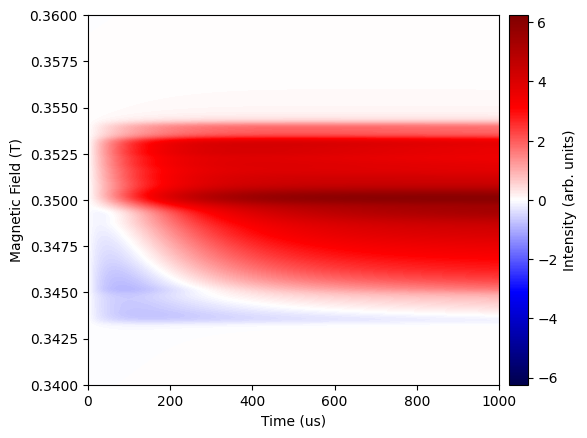

In [88]:
visualization.plot_2d_timeresolved(
    fields, time, spectrum_pop,
    time_unit="us"
)

In [89]:
tr_spectra_creator = spectra_manager.DensityTimeSpectra(  # The most parameters are the same
    freq=9.8e9,    # Frequency in Hz 
    sample=triplet,
    harmonic=0, # absorbtion
    context=context_red,
    temperature=300.0,
#    hamiltonian_mode="direct",
    device=device,
    dtype=dtype
)

# Define magnetic field range for simulation
fields = torch.linspace(0.340, 0.360, 1000, dtype=dtype, device=device)  # Field in Tesla

# Time axes in long and short time scale
tot_points = 1800
time = torch.linspace(0.0, 1 * 1e-3, tot_points, dtype=dtype, device=device)  # time in seconds, long time scale, up to 70ms

# Compute 2D spectra
spectrum_pop  = tr_spectra_creator(triplet, fields, time)

Text(0.5, 1.0, 'RWA Solution (Short Timescale)')

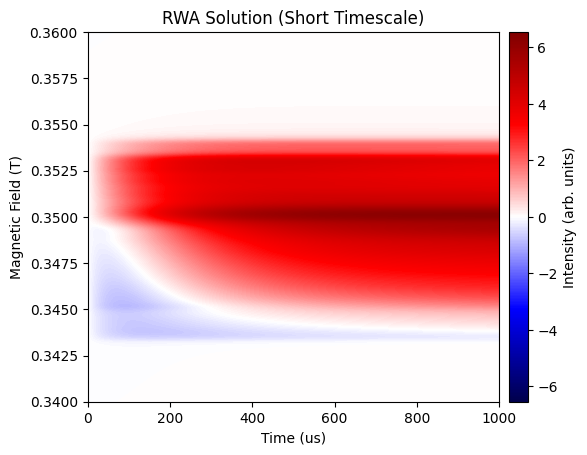

In [90]:
visualization.plot_2d_timeresolved(
    fields, time, spectrum_pop,
    time_unit="us"
)
plt.title("RWA Solution (Short Timescale)")

### Multiplication check

In [91]:
tr_spectra_creator = spectra_manager.CoupledTimeSpectra(  # The most parameters are the same
    freq=9.8e9,    # Frequency in Hz 
    sample=triplet_double,
    harmonic=0, # absorbtion
    context=context_lin_mul,
    temperature=300.0,
#    hamiltonian_mode="direct",
    device=device,
    dtype=dtype
)

# Define magnetic field range for simulation
fields = torch.linspace(0.340, 0.360, 1000, dtype=dtype, device=device)  # Field in Tesla

# Time axes in long and short time scale
tot_points = 800
time = torch.linspace(0.0, 100 * 1e-3, tot_points, dtype=dtype, device=device)  # time in seconds, long time scale, up to 70ms

# Compute 2D spectra
spectrum_pop  = tr_spectra_creator(triplet_double, fields, time)

Text(0.5, 1.0, 'RWA Solution (Short Timescale)')

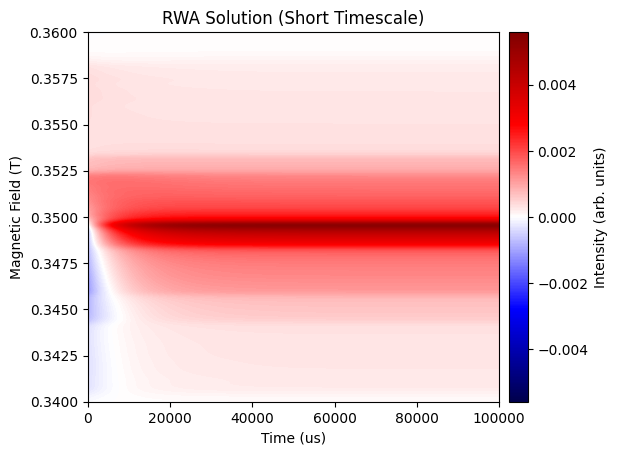

In [92]:
visualization.plot_2d_timeresolved(
    fields, time, spectrum_pop,
    time_unit="us"
)
plt.title("RWA Solution (Short Timescale)")

In [93]:
tr_spectra_creator = spectra_manager.CoupledTimeSpectra(  # The most parameters are the same
    freq=9.8e9,    # Frequency in Hz 
    sample=triplet_double,
    harmonic=0, # absorbtion
    context=context_red_mul,
    temperature=300.0,
#    hamiltonian_mode="direct",
    device=device,
    dtype=dtype
)

# Define magnetic field range for simulation
fields = torch.linspace(0.340, 0.360, 1000, dtype=dtype, device=device)  # Field in Tesla

# Time axes in long and short time scale
tot_points = 800
time = torch.linspace(0.0, 100 * 1e-3, tot_points, dtype=dtype, device=device)  # time in seconds, long time scale, up to 70ms

# Compute 2D spectra
spectrum_pop  = tr_spectra_creator(triplet_double, fields, time)

Text(0.5, 1.0, 'RWA Solution (Short Timescale)')

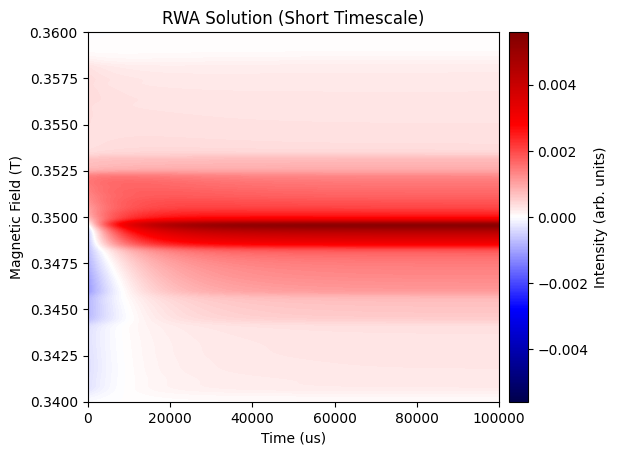

In [94]:
visualization.plot_2d_timeresolved(
    fields, time, spectrum_pop,
    time_unit="us"
)
plt.title("RWA Solution (Short Timescale)")